In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("Data/news_dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns)

Dataset shape: (6000, 5)
                                               title  \
0   WATCH: Trump Just Told All The Anti-Gay Bigot...   
1  China backs U.N. call for justice in Yemen, U....   
2  THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...   
3  WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...   
4  Lawmakers aim to delay U.S. ceding control of ...   

                                                text       subject  \
0  A whole lot of evangelical Trump voters just d...          News   
1  GENEVA (Reuters) - China signaled on Wednesday...     worldnews   
2                                                         politics   
3  THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...      politics   
4  WASHINGTON (Reuters) - Critics of a plan for t...  politicsNews   

                  date  label  
0    November 13, 2016      0  
1  September 13, 2017       1  
2         Feb 16, 2017      0  
3         Nov 15, 2015      0  
4  September 13, 2016       1  
Index(['title', 'text', '

In [3]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    6000 non-null   object
 1   text     6000 non-null   object
 2   subject  6000 non-null   object
 3   date     6000 non-null   object
 4   label    6000 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 234.5+ KB
None

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Label distribution:
label
0    3000
1    3000
Name: count, dtype: int64


In [4]:
df["combined_text"] = (
    df["title"].fillna("") + " " +
    df["text"].fillna("") + " " +
    df["subject"].fillna("")
)

print(df["combined_text"].head())

0     WATCH: Trump Just Told All The Anti-Gay Bigot...
1    China backs U.N. call for justice in Yemen, U....
2    THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...
3    WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...
4    Lawmakers aim to delay U.S. ceding control of ...
Name: combined_text, dtype: object


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df["combined_text"])

print("TF-IDF shape:", X.shape)

TF-IDF shape: (6000, 1000)


In [6]:
from sklearn.decomposition import PCA

# Convert sparse matrix to dense
X_dense = X.toarray()

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_dense)

print("PCA shape:", X_pca.shape)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total explained variance:")
print(pca.explained_variance_ratio_.sum())

PCA shape: (6000, 2)
Explained variance ratio:
[0.02531051 0.01684077]
Total explained variance:
0.04215127903588105


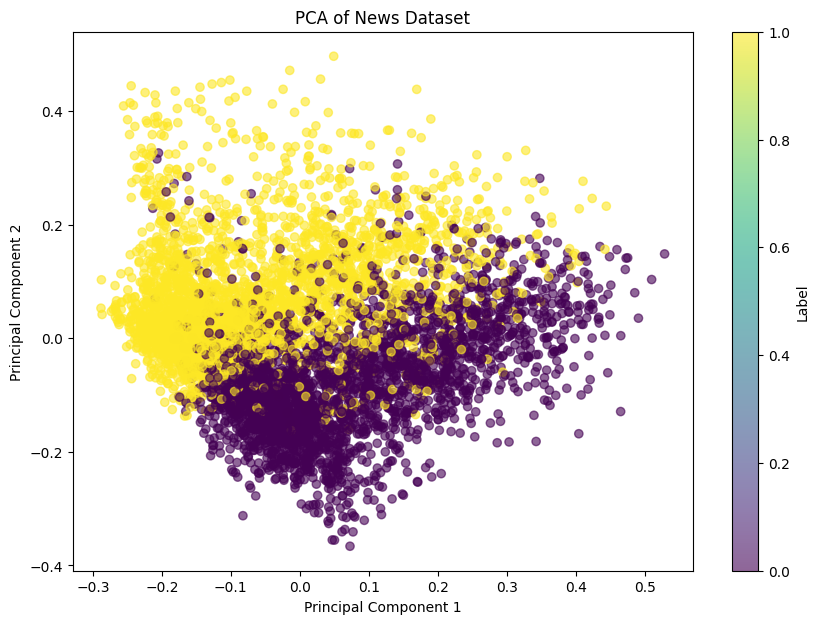

In [7]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["label"],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of News Dataset")
plt.colorbar(scatter, label="Label")
plt.show()

In [8]:
pca_50 = PCA(
    n_components=50,
    random_state=42
)

X_pca50 = pca_50.fit_transform(X_dense)

print("PCA-50 shape:", X_pca50.shape)

PCA-50 shape: (6000, 50)


In [9]:
from sklearn.manifold import TSNE

np.random.seed(42)

sample_size = 1500

indices = np.random.choice(
    len(df),
    size=sample_size,
    replace=False
)

X_sample = X_pca50[indices]
y_sample = df["label"].iloc[indices]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto",
    max_iter=750
)

X_tsne = tsne.fit_transform(X_sample)

print("t-SNE shape:", X_tsne.shape)

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

t-SNE shape: (1500, 2)


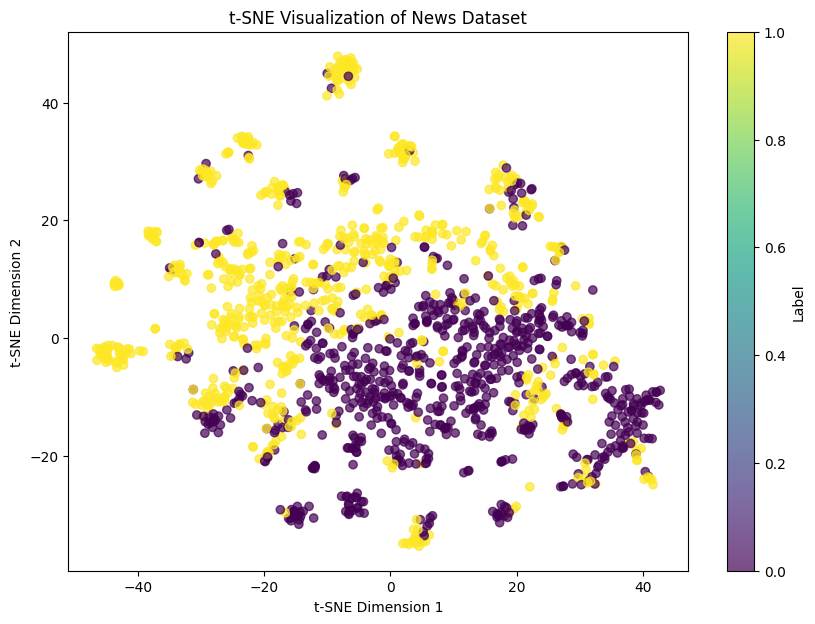

In [10]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_sample,
    alpha=0.7
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization of News Dataset")
plt.colorbar(scatter, label="Label")

plt.show()

In [11]:
from sklearn.decomposition import NMF

nmf = NMF(
    n_components=2,
    init="nndsvda",
    random_state=42,
    max_iter=300
)

X_nmf = nmf.fit_transform(X)

print("NMF shape:", X_nmf.shape)

print("Reconstruction error:")
print(nmf.reconstruction_err_)

NMF shape: (6000, 2)
Reconstruction error:
73.59265965938653


In [12]:
from sklearn.decomposition import NMF

nmf = NMF(
    n_components=2,
    init="nndsvda",
    random_state=42,
    max_iter=300
)

X_nmf = nmf.fit_transform(X)

print("NMF shape:", X_nmf.shape)

print("Reconstruction error:")
print(nmf.reconstruction_err_)

NMF shape: (6000, 2)
Reconstruction error:
73.59265965938653


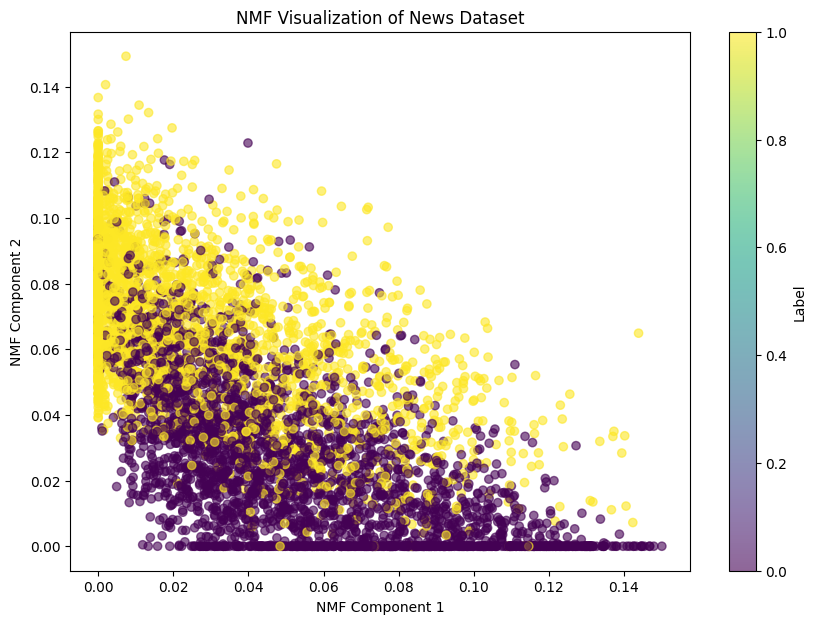

In [13]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_nmf[:, 0],
    X_nmf[:, 1],
    c=df["label"],
    alpha=0.6
)

plt.xlabel("NMF Component 1")
plt.ylabel("NMF Component 2")
plt.title("NMF Visualization of News Dataset")
plt.colorbar(scatter, label="Label")

plt.show()

In [14]:
feature_names = tfidf.get_feature_names_out()

for topic_idx, topic in enumerate(nmf.components_):

    top_words = [
        feature_names[i]
        for i in topic.argsort()[-15:][::-1]
    ]

    print(f"\nTopic {topic_idx + 1}:")
    print(", ".join(top_words))


Topic 1:
trump, clinton, donald, president, hillary, video, campaign, news, republican, just, white, obama, like, people, twitter

Topic 2:
said, state, government, reuters, united, president, states, police, year, north, court, security, china, military, worldnews


In [15]:
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler

# Standardize PCA-50 data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_pca50)

ica = FastICA(
    n_components=2,
    random_state=42,
    max_iter=500,
    whiten="unit-variance"
)

X_ica = ica.fit_transform(X_scaled)

print("ICA shape:", X_ica.shape)

ICA shape: (6000, 2)


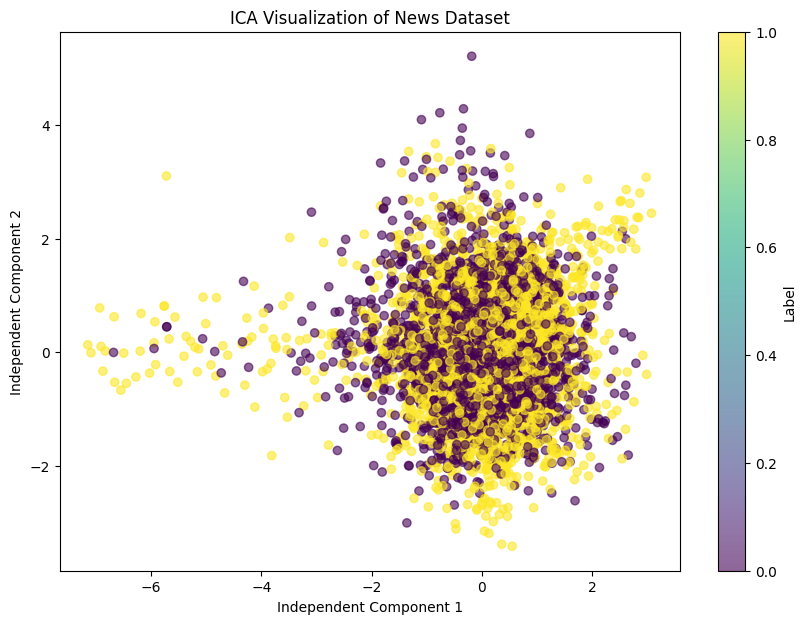

In [16]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_ica[:, 0],
    X_ica[:, 1],
    c=df["label"],
    alpha=0.6
)

plt.xlabel("Independent Component 1")
plt.ylabel("Independent Component 2")
plt.title("ICA Visualization of News Dataset")
plt.colorbar(scatter, label="Label")

plt.show()

In [17]:
from sklearn.manifold import Isomap

# Use a sample because Isomap is computationally expensive
np.random.seed(42)

sample_size = 1000

iso_indices = np.random.choice(
    len(df),
    size=sample_size,
    replace=False
)

X_iso_sample = X_pca50[iso_indices]
y_iso_sample = df["label"].iloc[iso_indices]

isomap = Isomap(
    n_components=2,
    n_neighbors=10
)

X_isomap = isomap.fit_transform(X_iso_sample)

print("Isomap shape:", X_isomap.shape)

Isomap shape: (1000, 2)


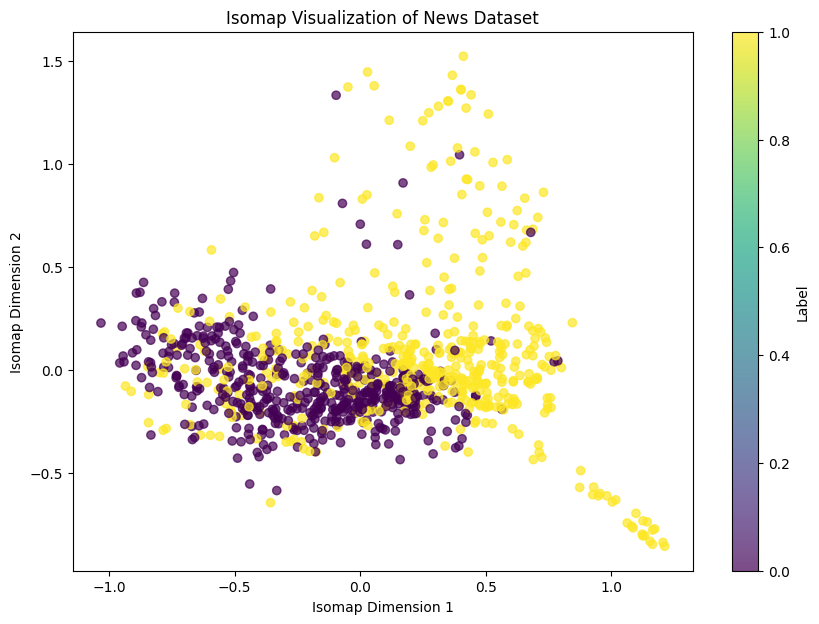

In [18]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_isomap[:, 0],
    X_isomap[:, 1],
    c=y_iso_sample,
    alpha=0.7
)

plt.xlabel("Isomap Dimension 1")
plt.ylabel("Isomap Dimension 2")
plt.title("Isomap Visualization of News Dataset")
plt.colorbar(scatter, label="Label")

plt.show()

In [19]:
print("========== DIMENSIONALITY REDUCTION RESULTS ==========")

print("Original TF-IDF:", X.shape)

print("PCA:", X_pca.shape)

print("t-SNE:", X_tsne.shape)

print("NMF:", X_nmf.shape)

print("ICA:", X_ica.shape)

print("Isomap:", X_isomap.shape)

========== DIMENSIONALITY REDUCTION RESULTS ==========
Original TF-IDF: (6000, 1000)
PCA: (6000, 2)
t-SNE: (1500, 2)
NMF: (6000, 2)
ICA: (6000, 2)
Isomap: (1000, 2)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA, NMF, FastICA
from sklearn.manifold import TSNE, Isomap
from sklearn.preprocessing import StandardScaler

# =====================================================
# 1. LOAD DATA
# =====================================================

df = pd.read_csv("Data/news_dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())

# =====================================================
# 2. COMBINE TEXT
# =====================================================

df["combined_text"] = (
    df["title"].fillna("") + " " +
    df["text"].fillna("") + " " +
    df["subject"].fillna("")
)

# =====================================================
# 3. TF-IDF
# =====================================================

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df["combined_text"])

print("\nTF-IDF:", X.shape)

X_dense = X.toarray()

# =====================================================
# 4. PCA
# =====================================================

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_dense)

print("\nPCA:")
print(X_pca.shape)
print("Explained variance:",
      pca.explained_variance_ratio_)
print("Total:",
      pca.explained_variance_ratio_.sum())

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["label"],
    alpha=0.6
)

plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Label")
plt.show()

# =====================================================
# 5. PCA 50 FOR EXPENSIVE METHODS
# =====================================================

pca50 = PCA(
    n_components=50,
    random_state=42
)

X_pca50 = pca50.fit_transform(X_dense)

# =====================================================
# 6. t-SNE
# =====================================================

np.random.seed(42)

tsne_idx = np.random.choice(
    len(df),
    size=1500,
    replace=False
)

X_tsne_input = X_pca50[tsne_idx]
y_tsne = df["label"].iloc[tsne_idx]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto",
    max_iter=750
)

X_tsne = tsne.fit_transform(X_tsne_input)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_tsne,
    alpha=0.7
)

plt.title("t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="Label")
plt.show()

# =====================================================
# 7. NMF
# =====================================================

nmf = NMF(
    n_components=2,
    init="nndsvda",
    random_state=42,
    max_iter=300
)

X_nmf = nmf.fit_transform(X)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_nmf[:, 0],
    X_nmf[:, 1],
    c=df["label"],
    alpha=0.6
)

plt.title("NMF")
plt.xlabel("NMF 1")
plt.ylabel("NMF 2")
plt.colorbar(label="Label")
plt.show()

# =====================================================
# 8. NMF TOP WORDS
# =====================================================

features = tfidf.get_feature_names_out()

for i, component in enumerate(nmf.components_):

    top_words = [
        features[j]
        for j in component.argsort()[-15:][::-1]
    ]

    print("\nNMF Topic", i + 1)
    print(top_words)

# =====================================================
# 9. ICA
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_pca50)

ica = FastICA(
    n_components=2,
    random_state=42,
    max_iter=500,
    whiten="unit-variance"
)

X_ica = ica.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_ica[:, 0],
    X_ica[:, 1],
    c=df["label"],
    alpha=0.6
)

plt.title("ICA")
plt.xlabel("Independent Component 1")
plt.ylabel("Independent Component 2")
plt.colorbar(label="Label")
plt.show()

# =====================================================
# 10. ISOMAP
# =====================================================

iso_idx = np.random.choice(
    len(df),
    size=1000,
    replace=False
)

X_iso_input = X_pca50[iso_idx]
y_iso = df["label"].iloc[iso_idx]

isomap = Isomap(
    n_components=2,
    n_neighbors=10
)

X_isomap = isomap.fit_transform(X_iso_input)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_isomap[:, 0],
    X_isomap[:, 1],
    c=y_iso,
    alpha=0.7
)

plt.title("Isomap")
plt.xlabel("Isomap 1")
plt.ylabel("Isomap 2")
plt.colorbar(label="Label")
plt.show()

# =====================================================
# 11. FINAL SUMMARY
# =====================================================

print("\n====================================")
print("DIMENSIONALITY REDUCTION SUMMARY")
print("====================================")

print("Original TF-IDF :", X.shape)
print("PCA             :", X_pca.shape)
print("t-SNE           :", X_tsne.shape)
print("NMF             :", X_nmf.shape)
print("ICA             :", X_ica.shape)
print("Isomap          :", X_isomap.shape)

Dataset shape: (6000, 5)
                                               title  \
0   WATCH: Trump Just Told All The Anti-Gay Bigot...   
1  China backs U.N. call for justice in Yemen, U....   
2  THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...   
3  WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...   
4  Lawmakers aim to delay U.S. ceding control of ...   

                                                text       subject  \
0  A whole lot of evangelical Trump voters just d...          News   
1  GENEVA (Reuters) - China signaled on Wednesday...     worldnews   
2                                                         politics   
3  THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...      politics   
4  WASHINGTON (Reuters) - Critics of a plan for t...  politicsNews   

                  date  label  
0    November 13, 2016      0  
1  September 13, 2017       1  
2         Feb 16, 2017      0  
3         Nov 15, 2015      0  
4  September 13, 2016       1  
